[Download notebook](ex_sea_ice_classification.ipynb)

![](https://img.shields.io/badge/CNES_AVISO-Contribution-%20?color=grey&labelColor=blue)

# Sea Ice Classification and local Leads/floes PDF analysis
This tutorial provides a step-by-step guide to analyzing polar region using SWOT data. It focuses on visualizing sea ice classification, binning ice concentration, and estimating ice freeboard (snow + ice thickness) using 2D histograms (Probability Density Functions, or PDFs).


## Tutorial Objectives
* Download Swot data with cycle/passes numbers, using ``altimetry_downloader_aviso``
* Select data intersecting a geographical area, using ``altimetry.io``
* Perform coordinates reprojection to ESPG:6931 using ``pyproj``
* Visualise sea ice classification using ``matplotlib``+``cartopy``
* Perform 2D binning on ice concentration, using ``pyinterp``
* Estimate ice freeboard using 2D histograms using ``numpy``+``matplotlib``

```{note}

Required environment to run this notebook:

* ``xarray``
* ``numpy``
* ``pyproj``
* ``pyinterp``
* ``matplotlib``+``cartopy``
* ``altimetry_downloader_aviso``: see [documentation](https://cnes.github.io/altimetry-downloader-aviso/).
* ``altimetry.io``: available [here](https://github.com/CNES/altimetry-io).

## Import + code

In [1]:
import warnings
import numpy as np
import xarray as xr
import os
from pathlib import Path

import pyinterp

from pyproj import Proj, Transformer, transform

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes

In [2]:
import logging
logging.basicConfig(level=logging.INFO)

In [3]:
def reproj_coords(ds, crs):
    """
    Transforms coordinates to a new crs
    """
    lat = ds["latitude"].values
    idx = np.where(lat >= LAT_BOUND)
    (_id, _) = idx
    sel = {'num_lines': slice(_id[0], _id[-1] + 1)}
    ds_crop = ds.isel(**sel)
    
    transformer = Transformer.from_crs(4326, crs)
    x_proj, y_proj = transformer.transform(
        ds_crop.latitude.data,
        ds_crop.longitude.data
    )
    ds_crop = ds_crop.assign(
        x_proj=(ds_crop.latitude.dims, x_proj),
        y_proj=(ds_crop.latitude.dims, y_proj)
    )
    return ds_crop

In [4]:
def set_carto(extent=None, nrows=1, ncols=1, projection=ccrs.NorthPolarStereo(), central_lon=0, figsize=(14, 12)):

    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        subplot_kw={'projection':projection},
        figsize=figsize,
        dpi=80
    )
    gl = axs.gridlines(draw_labels=True)
    gl.top_labels = gl.right_labels = False
    axs.coastlines(color="black", lw=0.5)
    divider = make_axes_locatable(axs)
    ax_cb = divider.new_horizontal(size="5%", pad=0.1, axes_class=plt.Axes)
    fig = plt.gcf()
    fig.add_axes(ax_cb)
    if extent:
        axs.set_extent(extent, crs=ccrs.PlateCarree())
        
    return fig, axs, ax_cb

def get_bins(lat_bound: float, resolution: float):
    """
    Generates a regular grid (xc_bins, yc_bins) in North polar stereographical projection
    """
    proj_polar = Proj(proj='stere', lat_0=90, lat_ts=70, lon_0=-45, datum='WGS84', units='m')

    x_min, y_min = proj_polar(0, lat_bound)
    x_max, y_max = 0, 0
    dist_max = np.abs(y_min)
    
    extent = dist_max
    num_bins = int(np.ceil((2 * extent) / resolution)) + 1

    xc_bins = np.linspace(-extent, extent, num_bins)
    yc_bins = np.linspace(-extent, extent, num_bins)

    return xc_bins, yc_bins

def plot_ice_conc(Xgeo, Ygeo, bin2d, crs, extent, central_latitude, fig_title, figsize=(10,15)):
    
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=ccrs.LambertAzimuthalEqualArea(central_latitude=central_latitude))

    ax.coastlines()
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')

    im = ax.pcolormesh(
        Xgeo,
        Ygeo,
        (1-bin2d.variable("mean")).T*100,
        transform=ccrs.epsg(crs),
        vmin=0,
        vmax=100,
        cmap="Spectral_r"
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", "3%", pad='7%', axes_class=maxes.Axes)
    plt.colorbar(im, label='Sea ice concentration [%]', cax=cax, location='bottom')

    ax.set_title(f"{fig_title} \n Mean sure leads (3) to sure leads and floes (3 and 0)\n1 and 2 values are ignored")

## Parameters

In [5]:
output_dir= Path.home() / "TMP_DATA"

cycle_number=[13]
half_orbits = [153, 155, 157, 181, 183, 209, 211, 237, 239, 265, 267, 291, 293, 295]

bbox=(-151, -109, 71, 78)

# coverage and resolution
LAT_BOUND = 60        # min absolute latitude 
RESOLUTION = 12500.    # pixels size in meters

## Download data using ``altimetry_downloader_aviso``

In [6]:
import altimetry_downloader_aviso as dl_aviso

In [7]:
dl_aviso.get(
    'SWOT_L3_LR_SSH_Unsmoothed', 
    output_dir=output_dir, 
    cycle_number=cycle_number, 
    pass_number=half_orbits,
)

INFO:altimetry_downloader_aviso.catalog_client.client:Fetching products from Aviso's catalog...
INFO:altimetry_downloader_aviso.catalog_client.granule_discoverer:Filtering SWOT_L3_LR_SSH_Unsmoothed product with filters {'cycle_number': [13], 'pass_number': [153, 155, 157, 181, 183, 209, 211, 237, 239, 265, 267, 291, 293, 295]}...
INFO:altimetry_downloader_aviso.core:14 files to download. 0 files already exist.
INFO:altimetry_downloader_aviso.tds_client:File /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_153_20240402T005441_20240402T014608_v2.0.1.nc downloaded.
INFO:altimetry_downloader_aviso.tds_client:File /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_155_20240402T023735_20240402T032902_v2.0.1.nc downloaded.
INFO:altimetry_downloader_aviso.tds_client:File /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_157_20240402T042028_20240402T051153_v2.0.1.nc downloaded.
INFO:altimetry_downloader_aviso.tds_client:File /home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_181_

['/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_153_20240402T005441_20240402T014608_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_155_20240402T023735_20240402T032902_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_157_20240402T042028_20240402T051153_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_181_20240403T005512_20240403T014639_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_183_20240403T023806_20240403T032932_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_209_20240404T005543_20240404T014710_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_211_20240404T023836_20240404T033001_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_237_20240405T005614_20240405T014741_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_239_20240405T023907_20240405T033032_v2.0.1.nc',
 '/home/atonneau/TMP_DATA/SWOT_L3_LR_SSH_Unsmoothed_013_265_2024

## Open data using ``altimetry.io``

In [8]:
from altimetry.io import AltimetryData, FileCollectionSource

Open data source

In [9]:
alti_data = AltimetryData(
    source=FileCollectionSource(
        path=output_dir,
        ftype="SWOT_L3_LR_SSH",
        subset="Unsmoothed"
    ),
)

Query data

In [10]:
ds = alti_data.query_orbit(
    cycle_number=cycle_number, 
    pass_number=half_orbits, 
    variables=["time", "latitude", "longitude", "quality_flag", "ssha_unedited"], 
    polygon=bbox
)
ds

INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (calval phase): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
INFO:fcollections.implementations.optional._predicates:The bbox intersects with pass numbers (science phase): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,

<xarray.Dataset> Size: 1GB
Dimensions:        (num_lines: 111916, num_pixels: 519)
Coordinates:
    time           (num_lines) datetime64[ns] 895kB dask.array<chunksize=(14200,), meta=np.ndarray>
    latitude       (num_lines, num_pixels) float64 465MB dask.array<chunksize=(3950, 260), meta=np.ndarray>
    longitude      (num_lines, num_pixels) float64 465MB dask.array<chunksize=(3950, 260), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    quality_flag   (num_lines, num_pixels) uint8 58MB dask.array<chunksize=(3950, 260), meta=np.ndarray>
    ssha_unedited  (num_lines, num_pixels) float64 465MB dask.array<chunksize=(3950, 260), meta=np.ndarray>
    cycle_number   (num_lines) uint16 224kB 13 13 13 13 13 13 ... 13 13 13 13 13
    pass_number    (num_lines) uint16 224kB 153 153 153 153 ... 295 295 295 295
Attributes: (12/42)
    Conventions:                     CF-1.7
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea Surface Height measured by Altimetry
    data_used:                       SWOT KaRIn L2_LR_SSH PGC0/PIC0 (NASA/CNE...
    doi:                             https://doi.org/10.24400/527896/A01-2024...
    ...                              ...
    geospatial_lon_min:              108.990992
    geospatial_lon_max:              275.949791
    date_modified:                   2025-03-06T20:03:00Z
    history:                         2025-03-06T20:03:00Z: Created by DUACS K...
    date_created:                    2025-03-06T20:03:00Z
    date_issued:                     2025-03-06T20:03:00Z

## 1. Coordinates reprojection to ESPG:6931

In [11]:
# Arctic
crs = 6931

In [12]:
ds_proj = reproj_coords(ds, crs)

In [13]:
ds_proj

<xarray.Dataset> Size: 2GB
Dimensions:        (num_lines: 110575, num_pixels: 519)
Coordinates:
    time           (num_lines) datetime64[ns] 885kB dask.array<chunksize=(12859,), meta=np.ndarray>
    latitude       (num_lines, num_pixels) float64 459MB dask.array<chunksize=(2609, 260), meta=np.ndarray>
    longitude      (num_lines, num_pixels) float64 459MB dask.array<chunksize=(2609, 260), meta=np.ndarray>
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    quality_flag   (num_lines, num_pixels) uint8 57MB dask.array<chunksize=(2609, 260), meta=np.ndarray>
    ssha_unedited  (num_lines, num_pixels) float64 459MB dask.array<chunksize=(2609, 260), meta=np.ndarray>
    cycle_number   (num_lines) uint16 221kB 13 13 13 13 13 13 ... 13 13 13 13 13
    pass_number    (num_lines) uint16 221kB 153 153 153 153 ... 295 295 295 295
    x_proj         (num_lines, num_pixels) float64 459MB -1.604e+06 ... -1.21...
    y_proj         (num_lines, num_pixels) float64 459MB 2.895e+06 ... 7.661e+05
Attributes: (12/42)
    Conventions:                     CF-1.7
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea Surface Height measured by Altimetry
    data_used:                       SWOT KaRIn L2_LR_SSH PGC0/PIC0 (NASA/CNE...
    doi:                             https://doi.org/10.24400/527896/A01-2024...
    ...                              ...
    geospatial_lon_min:              108.990992
    geospatial_lon_max:              275.949791
    date_modified:                   2025-03-06T20:03:00Z
    history:                         2025-03-06T20:03:00Z: Created by DUACS K...
    date_created:                    2025-03-06T20:03:00Z
    date_issued:                     2025-03-06T20:03:00Z

## 2. Visualization of Sea Ice Classification with Flag Application

* Learn how to apply quality flags to filter and visualize sea ice classification data.
* Understand how to identify and exclude artifacts for accurate analysis.



In [14]:
extent = [-109, -151, 71, 73]

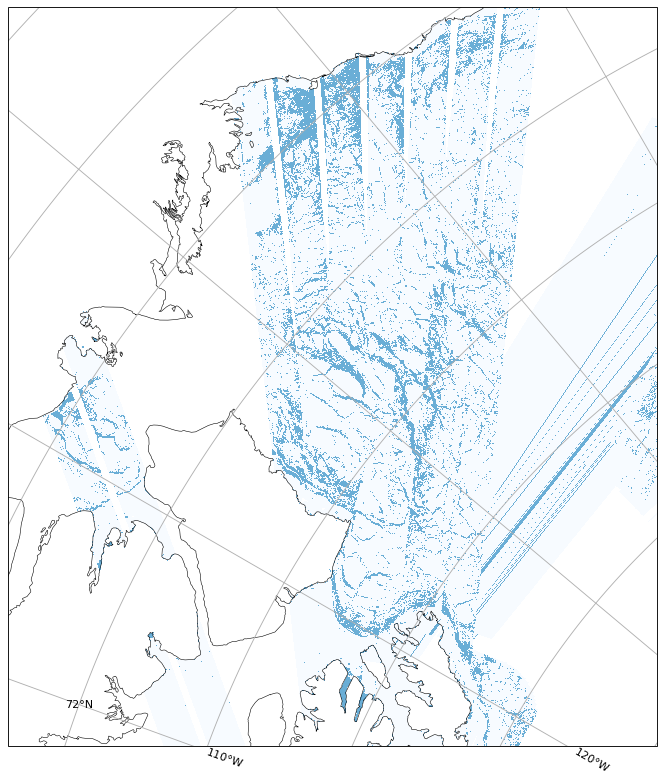

In [15]:
fig, ax, cb = set_carto(extent)
cb.remove()
# 19 = "ice_unsure"
# 20 = "ice"
# 101 = "not_on_sea"
# 102 = "no_data"

flag_sea_ice = xr.where(
    (ds_proj.quality_flag==19) | (ds_proj.quality_flag==20),
    0,
    xr.where((ds_proj.quality_flag==101) | (ds_proj.quality_flag==102),
        np.nan, # not_on_sea, no_data -> nan
        1
    )
)
    
ax.pcolormesh(
    ds_proj.longitude,
    ds_proj.latitude,
    flag_sea_ice,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    vmin=0,
    vmax=2,
)
    
fig = plt.gcf()

## 3. Binning and Visualization of Sea Ice Concentration

* Perform spatial binning to visualize sea ice concentration.
* Generate maps to highlight areas of interest for further analysis.

In [16]:
flag_sea_ice = xr.where(
    (ds_proj.quality_flag==20), 
    0, # ice -> 0
    xr.where((ds_proj.quality_flag==101) | (ds_proj.quality_flag==102),
        np.nan, # not_on_sea, no_data -> nan
        1 # ice_unsure -> 1
    )
)

In [17]:
xc_bins, yc_bins = get_bins(LAT_BOUND, RESOLUTION)

In [18]:
x = ds_proj.x_proj.data.ravel()
y = ds_proj.y_proj.data.ravel()
z = flag_sea_ice.data.ravel()
x_axis = pyinterp.Axis(np.array(xc_bins, dtype='float64'))
y_axis = pyinterp.Axis(np.array(yc_bins, dtype='float64'))

In [19]:
bin2d_flag_ice_conc = pyinterp.Binning2D(x_axis, y_axis, dtype=np.dtype('float64'))
bin2d_flag_ice_conc.push(x, y, z, simple=False)

### Plot result



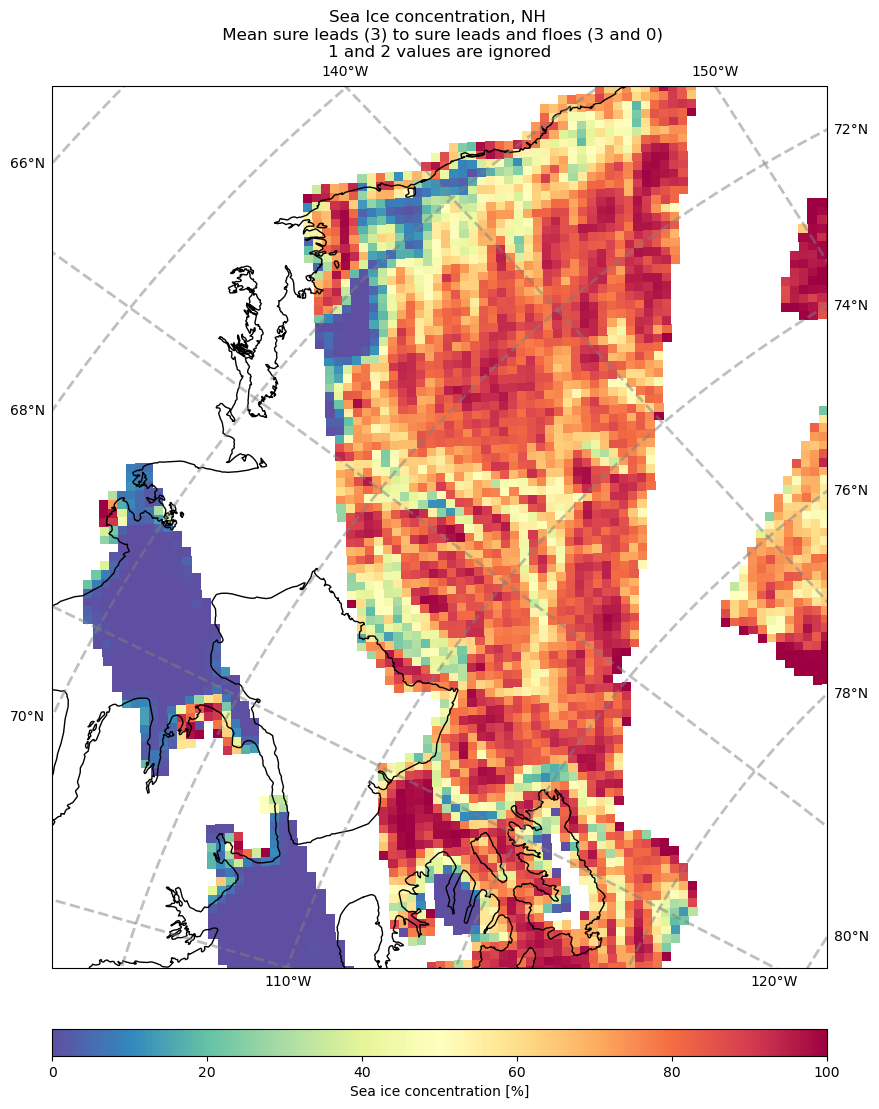

In [20]:
central_latitude = 74
Xgeo, Ygeo = np.meshgrid(xc_bins, yc_bins)
fig_title = f'Sea Ice concentration, NH'

plot_ice_conc(Xgeo, Ygeo, bin2d_flag_ice_conc, crs, extent, central_latitude, fig_title)

## 4. 2D Histogram (PDF) Analysis for Leads and Floes

* Calculate 2D histograms (PDFs) for sea ice leads (cracks) and floes (ice sheets).
* Compare the PDFs of leads and floes to derive differences in elevation.
* Use the difference between the two PDFs to estimate the freeboard (snow + ice thickness) from SWOT KaRIn, with an expected order of magnitude of ~20 cm.



In [21]:
ssha_leads = xr.where(flag_sea_ice==1, ds_proj.ssha_unedited, np.nan)
ssha_floes = xr.where(flag_sea_ice==0, ds_proj.ssha_unedited, np.nan)

In [22]:
hist, bins = np.histogram(ssha_leads, bins=np.arange(-0.2,0.5,0.01), density=True)
hist_floes, bins = np.histogram(ssha_floes, bins=np.arange(-0.2,0.5,0.01), density=True)

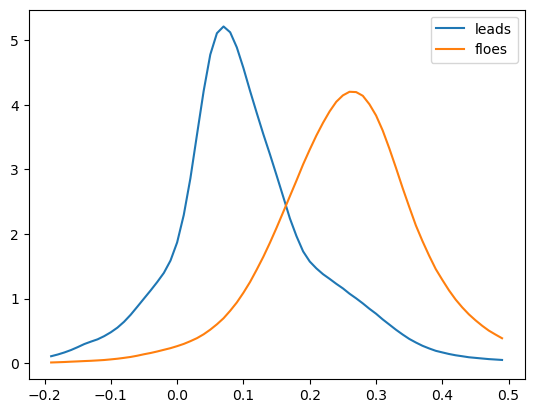

In [23]:
plt.figure()
plt.plot(bins[1:],hist, label="leads")
plt.plot(bins[1:],hist_floes, label="floes")
plt.legend()

[Download notebook](ex_sea_ice_classification.ipynb)